# 05 — Missing Data
**No todos los valores faltantes son iguales.**

## Tipos de missing (Rubin, 1976)

| Tipo | Nombre completo | Descripción | Ejemplo |
|---|---|---|---|
| **MCAR** | Missing Completely At Random | La probabilidad de faltar no depende de ninguna variable | Error aleatorio de sensor |
| **MAR** | Missing At Random | La probabilidad de faltar depende de otras variables observadas (no de sí misma) | Discount faltante solo en órdenes de UK |
| **MNAR** | Missing Not At Random | La probabilidad de faltar depende del valor que falta | Rating faltante solo en ratings bajos (insatisfacción) |

**Por qué importa:** MCAR → cualquier estrategia funciona. MAR → imputation condicional. MNAR → la imputación puede sesgar el modelo.

## Estrategias de imputación

| Estrategia | Cuándo | Riesgo |
|---|---|---|
| Eliminar filas | MCAR, < 5% missing | Pérdida de datos |
| Media / Mediana | Numéricas, MCAR/MAR | Subestima varianza |
| Moda | Categóricas, MCAR/MAR | Sobre-representa categoría dominante |
| KNN Imputer | MAR, relaciones entre features | Costoso en datasets grandes |
| Iterative Imputer | MAR, relaciones complejas | Costoso, puede overfittear |
| Indicador binario | MNAR | Preserva señal de "datos faltantes" |

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

rng = np.random.default_rng(42)
n   = 3000

categories = rng.choice(['Electronics','Clothing','Home','Sports','Books','Beauty'], n, p=[0.25,0.22,0.18,0.15,0.12,0.08])
countries  = rng.choice(['US','UK','DE','MX','BR','FR','CA'], n, p=[0.35,0.15,0.12,0.10,0.10,0.10,0.08])
price      = np.where(categories=='Electronics', rng.lognormal(4.5,0.8,n),
             np.where(categories=='Clothing',    rng.lognormal(3.5,0.6,n),
                                                 rng.lognormal(3.2,0.7,n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = rng.uniform(0.0, 0.40, n).round(2)
revenue    = (price * qty * (1 - discount)).round(2)
rating     = rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.40,0.25]).astype(float)

df = pd.DataFrame({
    'category': categories, 'country': countries,
    'price': price, 'quantity': qty, 'discount': discount, 'revenue': revenue, 'rating': rating,
})

# Inyectar missings con distintos mecanismos
df_miss = df.copy()

# MCAR: discount faltante completamente al azar
mcar_idx = rng.choice(n, size=int(n * 0.10), replace=False)
df_miss.loc[mcar_idx, 'discount'] = np.nan

# MAR: rating faltante más frecuentemente en UK y DE
mar_prob = np.where(df_miss['country'].isin(['UK', 'DE']), 0.25, 0.05)
mar_mask = rng.uniform(0, 1, n) < mar_prob
df_miss.loc[mar_mask, 'rating'] = np.nan

# MNAR: price faltante cuando el price es alto (datos de lujo no reportados)
mnar_prob = np.where(df_miss['price'] > df_miss['price'].quantile(0.80), 0.30, 0.02)
mnar_mask = rng.uniform(0, 1, n) < mnar_prob
df_miss.loc[mnar_mask, 'price'] = np.nan

print('Missing por columna:')
print((df_miss.isnull().mean() * 100).round(1).to_string())

Missing por columna:
category     0.0
country      0.0
price        7.2
quantity     0.0
discount    10.0
revenue      0.0
rating      11.1


## 1 — Diagnosticar el tipo de missing

In [2]:
# Test de Little (MCAR): si p > 0.05 → no se puede rechazar MCAR
# Aproximación manual: comparar distribución de otras variables entre filas con/sin missing

print('═' * 60)
print('DIAGNÓSTICO DE MECANISMO DE MISSING')
print('═' * 60)

for col_miss, check_cols in [
    ('discount', ['price', 'revenue', 'quantity']),
    ('rating',   ['price', 'revenue']),
    ('price',    ['revenue', 'quantity']),
]:
    mask_miss    = df_miss[col_miss].isnull()
    mask_present = ~mask_miss
    print(f'\n{col_miss} faltante ({mask_miss.mean():.1%})')

    for check in check_cols:
        g1 = df_miss.loc[mask_miss,    check].dropna()
        g2 = df_miss.loc[mask_present, check].dropna()
        if len(g1) > 5 and len(g2) > 5:
            t_stat, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            flag = '⚠️  MAR/MNAR probable' if p_val < 0.05 else '✓  MCAR probable'
            print(f'  vs {check:<12}: p={p_val:.4f}  {flag}')

print('\n→ Diferencias significativas en otras variables cuando X falta → MAR o MNAR.')

════════════════════════════════════════════════════════════
DIAGNÓSTICO DE MECANISMO DE MISSING
════════════════════════════════════════════════════════════

discount faltante (10.0%)
  vs price       : p=0.5099  ✓  MCAR probable
  vs revenue     : p=0.1248  ✓  MCAR probable
  vs quantity    : p=0.8633  ✓  MCAR probable

rating faltante (11.1%)
  vs price       : p=0.3966  ✓  MCAR probable
  vs revenue     : p=0.8690  ✓  MCAR probable

price faltante (7.2%)
  vs revenue     : p=0.0000  ⚠️  MAR/MNAR probable
  vs quantity    : p=0.2938  ✓  MCAR probable

→ Diferencias significativas en otras variables cuando X falta → MAR o MNAR.


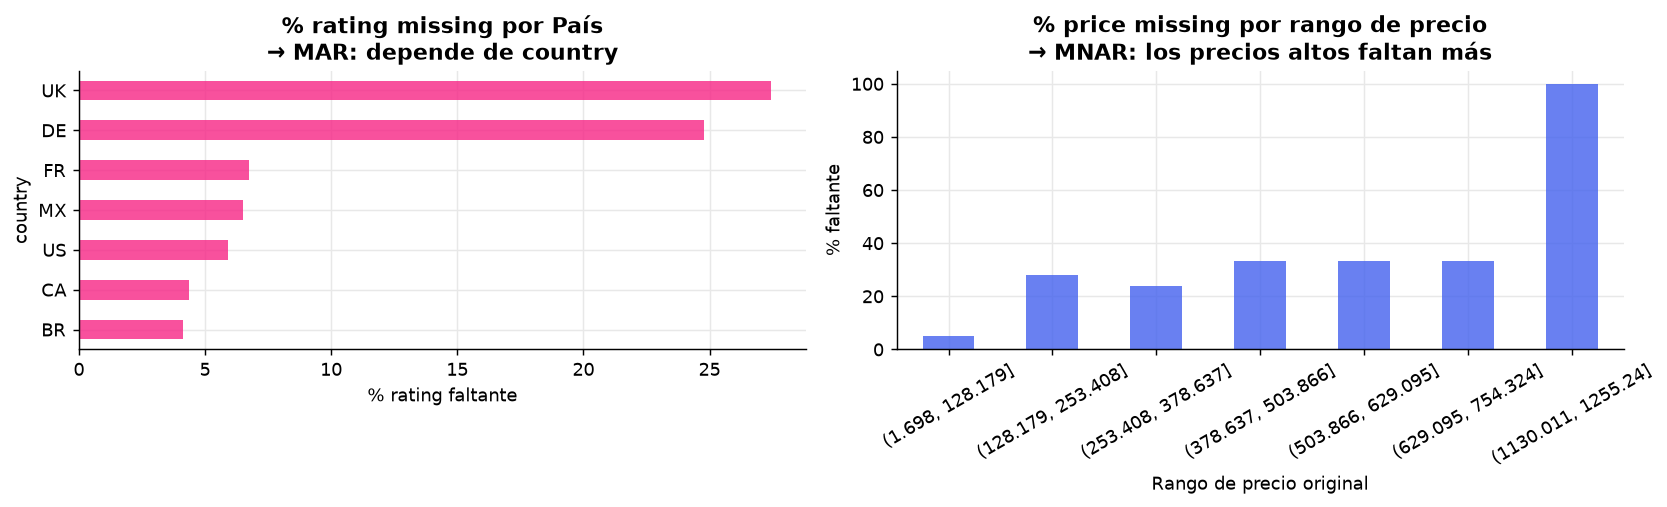

In [3]:
# Visualizar: ¿rating faltante varía por country? (Test MAR)
miss_by_country = df_miss.groupby('country')['rating'].apply(lambda x: x.isnull().mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

miss_by_country.sort_values(ascending=True).plot.barh(ax=axes[0], color='#f72585', alpha=0.8)
axes[0].set_xlabel('% rating faltante')
axes[0].set_title('% rating missing por País\n→ MAR: depende de country')

# ¿price faltante cuando price es alto? (Test MNAR)
price_bins = pd.cut(df['price'], bins=10)
miss_by_price = df_miss.groupby(price_bins)['price'].apply(lambda x: x.isnull().mean()) * 100
miss_by_price.plot.bar(ax=axes[1], color='#4361ee', alpha=0.8)
axes[1].set_xlabel('Rango de precio original')
axes[1].set_ylabel('% faltante')
axes[1].set_title('% price missing por rango de precio\n→ MNAR: los precios altos faltan más')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 2 — Estrategias de imputación: comparación

In [4]:
# Comparar imputaciones sobre 'discount' (MCAR → cualquiera funciona)
num_cols_imp = ['price', 'quantity', 'discount', 'revenue', 'rating']
X_miss = df_miss[num_cols_imp].copy()
X_true = df[num_cols_imp].copy()

imputers = {
    'Media':      SimpleImputer(strategy='mean'),
    'Mediana':    SimpleImputer(strategy='median'),
    'KNN (k=5)':  KNNImputer(n_neighbors=5),
    'Iterative':  IterativeImputer(max_iter=10, random_state=42),
}

print(f'{"Método":<15} {"RMSE discount":>15} {"RMSE rating":>12} {"RMSE price":>11}')
print('-' * 58)

for name, imp in imputers.items():
    X_imp = pd.DataFrame(imp.fit_transform(X_miss), columns=num_cols_imp)
    rmse_discount = ((X_imp['discount'] - X_true['discount'])**2).mean()**0.5
    rmse_rating   = ((X_imp['rating']   - X_true['rating'])**2).mean()**0.5
    rmse_price    = ((X_imp['price']    - X_true['price'])**2).mean()**0.5
    print(f'{name:<15} {rmse_discount:>15.4f} {rmse_rating:>12.4f} {rmse_price:>11.4f}')

Método            RMSE discount  RMSE rating  RMSE price
----------------------------------------------------------
Media                    0.0371       0.3690     41.7315
Mediana                  0.0372       0.3751     44.7517
KNN (k=5)                0.0319       0.4074     22.9017
Iterative                0.0363       0.3682     17.5408


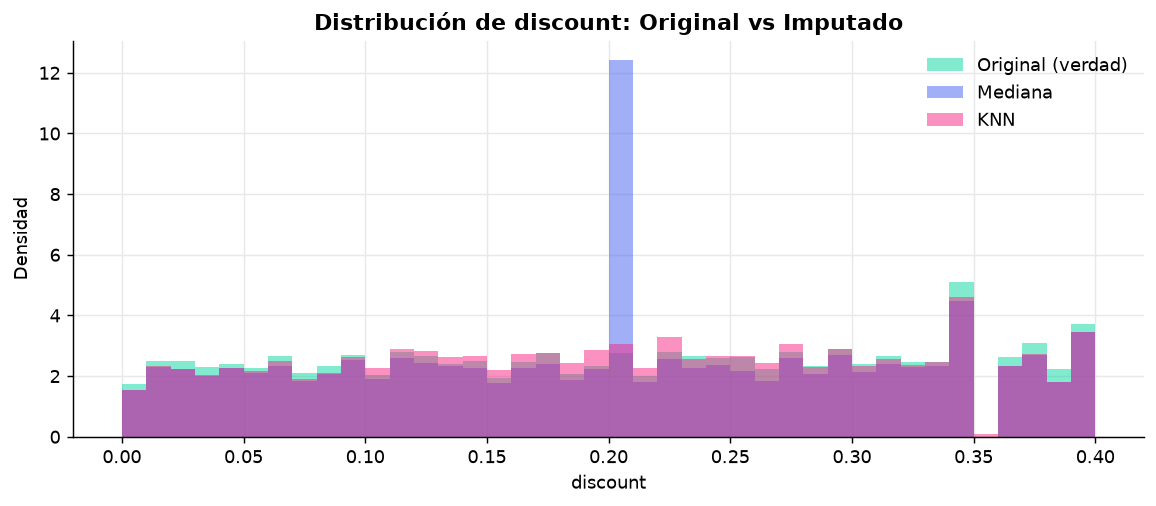

Mediana crea pico artificial en el valor de mediana.
KNN preserva mejor la distribución original.


In [5]:
# Visualizar efecto de la imputación sobre la distribución
imp_median = SimpleImputer(strategy='median')
imp_knn    = KNNImputer(n_neighbors=5)

disc_median = pd.DataFrame(imp_median.fit_transform(X_miss), columns=num_cols_imp)['discount']
disc_knn    = pd.DataFrame(imp_knn.fit_transform(X_miss),    columns=num_cols_imp)['discount']

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['discount'],      bins=40, alpha=0.5, density=True, color='#06d6a0', label='Original (verdad)')
ax.hist(disc_median,         bins=40, alpha=0.5, density=True, color='#4361ee', label='Mediana')
ax.hist(disc_knn,            bins=40, alpha=0.5, density=True, color='#f72585', label='KNN')
ax.set_xlabel('discount'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de discount: Original vs Imputado')
ax.legend()
plt.tight_layout()
plt.show()
print('Mediana crea pico artificial en el valor de mediana.')
print('KNN preserva mejor la distribución original.')

## 3 — MNAR: indicador binario como feature

In [6]:
# Para MNAR (price), la ausencia del valor es información en sí misma
df_with_indicator = df_miss.copy()
df_with_indicator['price_was_missing'] = df_miss['price'].isnull().astype(int)
df_with_indicator['price'] = df_miss['price'].fillna(df_miss['price'].median())

print('Comparar revenue según si price faltaba o no:')
comparison = df_with_indicator.groupby('price_was_missing')['revenue'].agg(['mean','median','count'])
comparison.index = ['price presente', 'price faltante']
print(comparison.round(2).to_string())

t, p = stats.mannwhitneyu(
    df_with_indicator[df_with_indicator['price_was_missing']==1]['revenue'].dropna(),
    df_with_indicator[df_with_indicator['price_was_missing']==0]['revenue'].dropna(),
)
print(f'\nMann-Whitney p={p:.4f} → {"diferencia significativa" if p < 0.05 else "sin diferencia"}')
print('→ Si revenue difiere entre grupos: price_was_missing es un predictor útil — incluirlo como feature.')

Comparar revenue según si price faltaba o no:
                  mean  median  count
price presente  161.26   87.22   2783
price faltante  411.01  292.31    217

Mann-Whitney p=0.0000 → diferencia significativa
→ Si revenue difiere entre grupos: price_was_missing es un predictor útil — incluirlo como feature.


## Resumen — Decisión de imputación

```
¿Cuánto falta?
  > 50%  → considerar eliminar columna
  20-50% → imputación con cuidado + indicador binario
  < 20%  → imputación estándar

¿Qué mecanismo?
  MCAR → SimpleImputer (media/mediana) es suficiente
  MAR  → KNNImputer o IterativeImputer
  MNAR → Imputar + agregar columna indicadora (was_missing=1)
```

**Siguiente:** `06_outliers.ipynb`